In [1]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import pandas as pd
import os
from scipy.optimize import fsolve
import numpy as np

In [2]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is not available


In [3]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
        debug_shapes (bool): print assembled tensor shapes before solve
    """

    def __init__(
        self,
        discrete_equations,
        nchunk=1,
        rtol=1.0e-5,
        atol=1.0e-3,
        initial_rho_m=1.0e12,
        debug_shapes=False,
    ):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m
        self.debug_shapes = debug_shapes

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading,
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        if self.debug_shapes:
            print("--- SolveStrain shape debug ---")
            print(f"time shape: {tuple(time.shape)}")
            print(f"temperature shape: {tuple(temperature.shape)}")
            print(f"loading shape: {tuple(loading.shape)}")
            print(f"control shape: {tuple(control.shape)}")
            print(f"assembled forces shape: {tuple(forces.shape)}")
            print(f"assembled state0 shape: {tuple(state0.shape)}")
            print(f"len(forces): {len(forces)}")
            print(f"nchunk: {self.nchunk}")

            try:
                force_parts = self.discrete_equations.forces_asm.split_by_variable(neml2.Tensor(forces, 2))
                print("forces_asm split shapes:")
                for name, value in force_parts.items():
                    print(f"  {str(name)}: {tuple(value.torch().shape)}")
            except Exception as e:
                print(f"forces_asm split failed: {e}")

            try:
                state_parts = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(state0, 1))
                print("state_asm split shapes:")
                for name, value in state_parts.items():
                    print(f"  {str(name)}: {tuple(value.torch().shape)}")
            except Exception as e:
                print(f"state_asm split failed: {e}")

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        return result[..., 0:1]

In [5]:
nchunk = 50
nmodel = neml2.load_model("new_model_tensile.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["Bk_X", "C_X", "E_X", "E_Y", "G_X", "G_Y", "H_0_X", "T_0_X", "T_ref_X", "T_ref_Y",
                                                                            "athermal_alpha", "athermal_b", "elasticity_nu", "flow_rate_b", "g_X", "k1_X", "k2_X",
                                                                            "rho_m_rate_L", "shear_athermal_m", "shear_eff_m", "sy_X", "tau_p_X", "v_disl_L", "v_disl_a",
                                                                            "v_disl_b", "v_disl_h", "v_disl_p", "v_disl_q"]), nchunk=nchunk)

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: Bk_X [Scalar][Double][cpu]
            Bk_Y [Scalar][Double][cpu]
            C_X [Scalar][Double][cpu]
            C_Y [Scalar][Double][cpu]
            E_X [Scalar][Double][cpu]
            E_Y [Scalar][Double][cpu]
            G_X [Scalar][

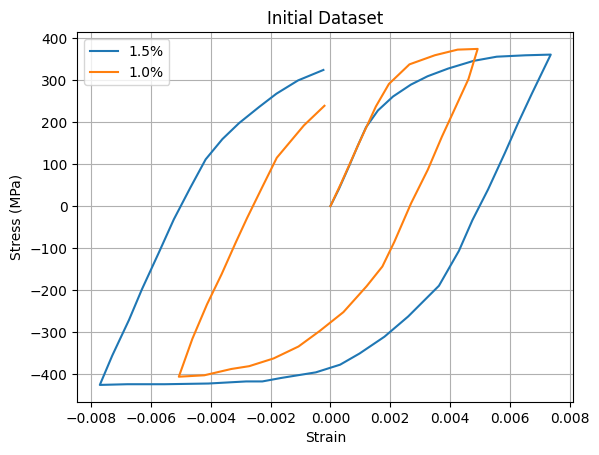

In [6]:
path = '/home/colinmoose/neml2/cmg_projects/cyclic_data'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if '1.5' in filename:
            sr_label = '1.5'
        elif '1.0' in filename:
            sr_label = '1.0'
        else:
            sr_label = 'unknown'
        
        new_df = df.rename(columns={'x':f'{sr_label}_strain', 'y':f'{sr_label}_stress'})
        data_frames[sr_label] = new_df
strain_data = {}
stress_data = {}

for sr_label, df in data_frames.items():
    strain_col = f'{sr_label}_strain'
    stress_col = f'{sr_label}_stress'
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[sr_label] = strain
    stress_data[sr_label] = stress

# Plot initial dataset
plt.figure()
for sr_label in strain_data:
    plt.plot(strain_data[sr_label].cpu().numpy(), stress_data[sr_label].cpu().numpy(), label=f"{sr_label}%")
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Initial Dataset')
plt.grid()
plt.legend()
plt.show()


In [7]:
n_cycles = 10
points_per_cycle = 200   # controls sharpness of triangle wave peaks

ntemperature = 1
nrate = 1
ntime = n_cycles * points_per_cycle  # total time steps
nbatch = 2
rates = torch.tensor([3.0e-3], device=device)
temperatures = torch.tensor([550.0], device=device)
ranges = torch.tensor([0.01, 0.015], device=device)


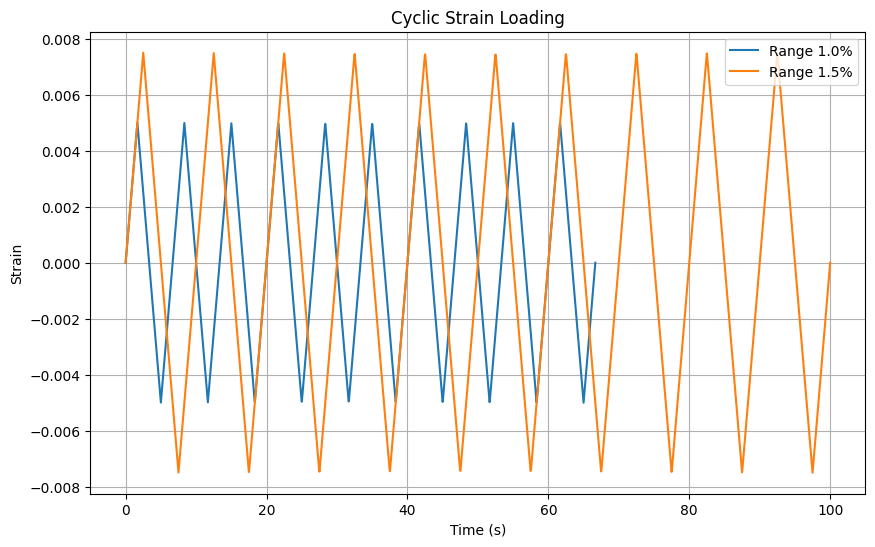


--- Full Input Tensors ---
time: torch.Size([2000, 2, 1])
temperature: torch.Size([2000, 2, 1])
loading: torch.Size([2000, 2, 6])


In [8]:
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

plt.figure(figsize=(10, 6))
for i, s_range in enumerate(ranges):
    amplitude = s_range.item() / 2.0
    period = 2.0 * s_range.item() / rates[0].item()
    total_time = n_cycles * period

    time_values = torch.linspace(0.0, total_time, ntime, device=device)

    strain_values = (2.0 * amplitude / torch.pi) * torch.arcsin(
        torch.sin(2.0 * torch.pi * time_values / period)
    )

    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    temperature[:, i, 0] = temperatures[0]

    plt.plot(time_values.cpu().numpy(), strain_values.cpu().numpy(),
             label=f"Range {s_range.item()*100:.1f}%")

plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Cyclic Strain Loading")
plt.legend()
plt.grid()
plt.show()

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")


In [10]:
with torch.no_grad():
    stress = model(time, temperature, loading)

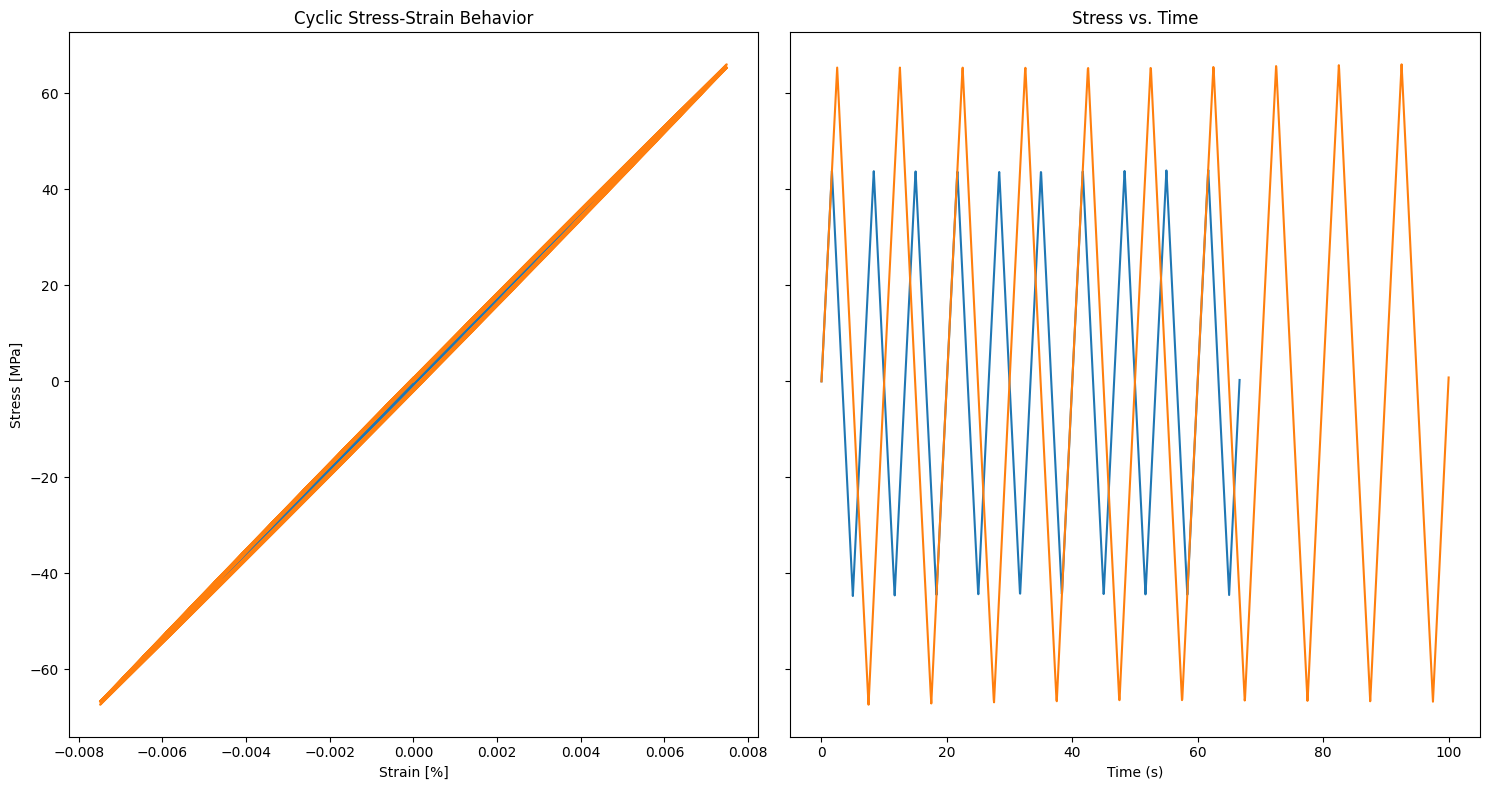

In [20]:
fig, ax = plt.subplots(1,2, sharey=True, figsize=(15,8))
for i, s_range in enumerate(ranges):
    ax[0].plot(loading[:,i,0].cpu().numpy(), stress[:,i,0].cpu().numpy(), label=f'{s_range.item()*100}%')
    ax[0].set_xlabel('Strain [%]')
    ax[0].set_ylabel('Stress [MPa]')
    ax[0].set_title('Cyclic Stress-Strain Behavior')
    ax[1].plot(time[:,i,0].cpu().numpy(), stress[:,i,0].cpu().numpy(), label=f'{s_range.item()*100}%')
    ax[1].set_xlabel('Time (s)')
    ax[1].set_title('Stress vs. Time')
plt.tight_layout()
plt.show()